<a href="https://colab.research.google.com/github/Rahul7587/invoice-ocr-application/blob/main/notebooks/ocr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import kagglehub

# Download latest version directly into your environment/cache
path = kagglehub.dataset_download("senju14/ocr-dataset-of-multi-type-documents")

Using Colab cache for faster access to the 'ocr-dataset-of-multi-type-documents' dataset.


In [46]:
print(path)

/kaggle/input/ocr-dataset-of-multi-type-documents


In [47]:
from datasets import load_dataset
ds = load_dataset('/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/invoice/train')

Resolving data files:   0%|          | 0/1556 [00:00<?, ?it/s]

In [48]:
ds_images = load_dataset('imagefolder', data_dir='/root/.cache/kagglehub/datasets/senju14/ocr-dataset-of-multi-type-documents/versions/3/invoice/train')

Resolving data files:   0%|          | 0/1556 [00:00<?, ?it/s]

In [49]:
print(ds)
print(ds_images)

DatasetDict({
    train: Dataset({
        features: ['file_id', 'entities', 'ocr_boxes'],
        num_rows: 778
    })
})
DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 778
    })
})


In [50]:
!pip -q install pytesseract opencv-python-headless datasets kagglehub tqdm

from pathlib import Path
from typing import Any
import re
import unicodedata

import cv2
import numpy as np
import pandas as pd
import pytesseract
from tqdm.auto import tqdm

sample = ds_images['train'][0]
print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=463x1013 at 0x78A9309ED590>}


In [51]:
assert 'ds' in globals() and 'ds_images' in globals()

assert len(ds['train']) == len(ds_images['train']), "Annotations and images are not aligned."

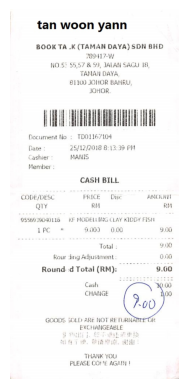

In [52]:
import matplotlib.pyplot as plt

plt.imshow(sample['image'])
plt.axis('off')
plt.show()

In [53]:
# Testing OCR on the above image, without any preprocessing
text = pytesseract.image_to_string(sample['image'])
print(text)

tan woon yann

BOOK TA -K (TAMAN DAYA) SDN BHD
TBO T-W
NO.5? $5.57 & 59, JALAN SAGU 18,
TAMAN DAYA
81100 JOHOR BARU,
JOHOR.

HAM TANT

Document No : TDO1167104

Date 25/12/2018 8:13:39 PM
Cashier MANIS.
Member
CASH BILL
CODE/DESC PRICE Dise AMOUIHT
Quy RM RM
9556929040118 KF MODELLING CLAY KIDDY FISH
1PC + 9.00) 0.00 9.00
Total : 9,00
Rour ding Adjustment 0.00
Round. :d Total (RM): 9.00
Cash 7 40.00.
CHANGE 00

GOODS SOLD ARE NOT RETURNAR
EXCHANGEABLE

THANK YOU
PLEASE COME AGAIN t



Image without any preprocessing


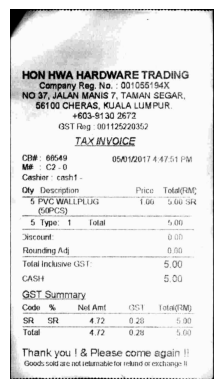

Corresponding OCR output
HON HWA HARDWARE TRADING
i Company Reg. No. : 001055194%
NO 37, JALAN MANIS 7, TAMAN SEGAR,
56100 CHERAS, KUALA LUMPUR.
+603-91 30 2672
GST Rog : 001125220352

TAX INVOICE

CBH#: 66549 O5A01/2017 4:47:51 PM
M# : C2-0
Cashier: cash? -
Qty Description Price Total(RM}
“Sh PVC WALLPLUG —————~CGC (GSS GU SR
OPCS) Cn

& Type: 1 [otal 4 00
Discount: 0 On
Rounding Adj 0.40
Total Inclusive GS T° 5.00
CASH 5.00

GST Summary
Code % = NetAmt GS! total),

SR SR - A472 _ i) 2G 5.00
Total 4.72 0.2% 4.00

Thank you !| & Please come again !!
Goods sold ate nol telurmable for fehund of exchand: |

LL ee, a, a a!

Image without any preprocessing


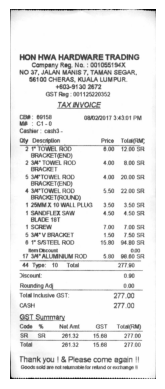

Corresponding OCR output
—_—o

HON HWA HARDWARE TRADING
Company Reg. Na. : 001055194X
NO 37, JALAN MANIS 7, TAMAN SEGAR,
§6100 CHERAS, KUALA LUMPUR.

+603-91 30 2672
GST Reg : 001125220352
TAX INVOICE
CB#: 69158 08/02/2017 3:43:01 PM
M# : C1-0
Cashier : cash3 -
Oly Description Price Totai(RM}
2 1° TOWEL ROD 6.00 12.00 SR
BRACKET(END)
2 344" TOWEL ROD 4.00 98.00SR
BRACKET
5 34" TOWEL ROD 4.00 20.00SR
BRACKET(END)
4 3/4"TOWEL ROD §50 22.00SR |
BRACKET(ROUND) |
1 25MMX10WALLPLUG 340 3.50SR
1 SANDFLEX SAW 450 4.50SR
BLADE 18T
1 SCREW 7.00 7.00SR
5 3/4" V BRACKET 150 7.50SR
6 1° SSTEEL ROD 15.80 94.80SR
item Discount 0.00
17 3/4" ALUMINIUM ROD §.80 98.60SR
44 Type: 10 Total 277.90
discount: 0.90
Rounding Adj 0.00
Total Inclusive GST: 277.00
CASH 277.00
GST Summary

Code % Nef Amt GST  Total(RM)
SR SR 261.32 15.68 277.00
Total 261.32 15.68 277.00

Thank you ! & Please come again !!
Goods sold are not returnable for refund or exchange |!


Image without any preprocessing


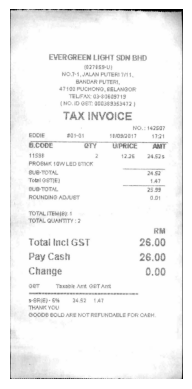

Corresponding OCR output
EVERGREEN LIGHT SDN BHD
(827ES9-U1}
ND7+1, JALAN PUTER? 7/14,
BANDAR PUTER,
47100 PUCHONG, EELANGOR
TELFAN: 0380609719
(NOD GET: dO0s89252472 }

TAA INVOICE

EDDIE #Ot-GY 1
B.COBE ary
11898 z
PROEME {OW LED ETICK
SUB-TOTAL

Tote! GETIE}

SUB-TOTAL

ROUNDING ADLET

TOTAL ITEM(Er 1
TOTAL QUANTITY ; 2
Total ici GST
Pay Cash
Change

GET Taxable Amt G&T Amt

HO.:
efsa0t7

W/PRICE
12.26

1427507
Ths
ANT

24.575

24,52

147

25,99

o.04

RE

26.00
26.00

SERIE) - 6% R452 1AT
THAN YOU

0.00

GOODE GOLD ARE NOT REFUNDABLE FOF CAEH.


Image without any preprocessing


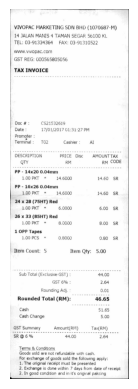

Corresponding OCR output
VIVOPAC MARKETING SDN BHD (1070687-M)

14 JALAN MANIS 4 TAMAN SEGAR 56100 KL
TEL: 03-91334364 FAX: 03-91310522

WWW. vivopac.com
GST REG: 000565805056

TAX INVOICE
Doc # : C$21532619
Date : 7/01/2017 01:31:27 PM
Promoter :
Terminal: 702 Cashier : Al
‘DESCRIPTION PRICE Disc | AMOUNTTAX
QTY RM RM CODE
PP - 14x20 0.04mm
1.00 PKT * 14.6600 14.60 SR
PP - 16x26 0.04mm
1.00 PKT * 14.6000 14.60 SR
24 x 28 (75HT) Red
1.00 PKT * 6.0000 6.00 SR
26 x 33 (8SHT) Red
1.00 PKT * 8.0000 8.00 SR
1 OPP Tapes
1.00 PCS * 0,8000 9.80 SR
~ Ttem Count: 5 Item Qty: 5.00
"Sub Total (Exclusive GST): 44.00
GST 6% : 2.64
Rounding Adj. : 0.01
Rounded Total (RM): 46.65
Cash 51.65
Cash Change 5.00
GST Summary Amount(RM) Tax(RM)
SR @6% 44.00 2.64

Terms & Conditions

Goods sold are not refundable with cash.

For exchange of goods sold the following apply:

1. The original receipt must be presented

2. Exchange is done within 7 days from date of receipt

2. In good condition and in it's origina

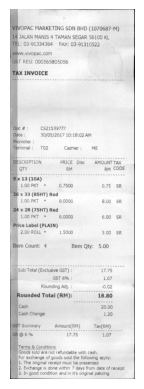

Corresponding OCR output
OPAC MARKETING SDN BHD (1070687-M)

JALAN MANIS 4 TAMAN SEGAR 56100 KL
L: 03-91334364 FAX: 03-91310522

.vivopac.com
T REG: 000565805056

#: CS21539777
30/05/2017 10:18:02 AM

SCRIPTION PRICE Disc | AMOUNT TAX
QTY RM RM CODE

x 13 (10A)
1.00PKT * 0.7500 0.75 SR

6 x 33 (8SHT) Red
1.00 PKT * 8.0000 8.00 SR

4 x 28 (75HT) Red
 1.00PKT * — 6.0000 6.00 SR
Price Label (PLAIN)
) 2.00 ROLL * 1.5000 3.00 SR
‘Ttem Count: 4 Item Qty: 5.00
Sub Total (Exclusive GST): 17.75
GST 6% : 1.07

Rounding Adj. : -0.02

ounded Total (RM): 18.80
20.00

Cash Change 1.20

Summary Amount(RM) Tax(RM)

Terms & Conditions

Goods sold are not refundable with cash.

For exchange of goods sold the following apply:

1. The original receipt must be presented

2. Exchange is done within 7 days from date of receipt

2. In good condition and in it's original pakcing


Image without any preprocessing


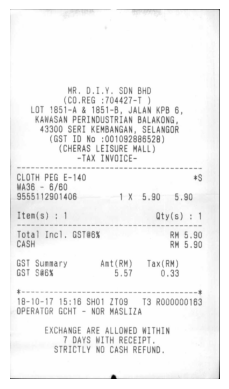

Corresponding OCR output
MR. D.I.Y. SDN BHD

(CO.REG :704427-T )
LOT 1851-A & 1851-B, JALAN KPB 6,
KAWASAN PERINDUSTRIAN BALAKONG,
43300 SERI KEMBANGAN, SELANGOR

(GST ID No :001092886528)
(CHERAS LEISURE MALL)
-TAX INVOICE-

CLOTH PEG E-140 *§
WA36 - 6/60

9555112901406 1X 5,90 5.90
Item(s) : 1 Qty(s) : 1
Total Incl. GST@6% RM 5,90
CASH RM 5.90
GST Summary Amt(RM) = Tax(RM)

GST S@6% 5.57 0.93

Pan saan en enn men woes *

18-10-17 15:16 SHO! ZT09 13 RO00000163
OPERATOR GCHT - NOR MASLIZA

EXCHANGE ARE ALLOWED WITHIN
7 DAYS WITH RECEIPT.
STRICTLY NO CASH REFUND.


Image without any preprocessing


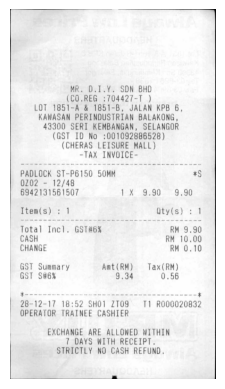

Corresponding OCR output
MR. D.I.Y. SON BHD
(CO.REG :704427-T )
LOT 1851-A & 1851-B, JALAN KPB 6,
KAWASAN PERINDUSTRIAN BALAKONG,
43300 SERI KEMBANGAN, SELANGOR
(GST ID No :001092886528)
(CHERAS LEISURE MALL)
~TAK INVOICE-

PADLOCK sT- P6150 50MM *§
0202 - 12/48

6942131561507 1X 9.90 9,90
Ttan(s) “| Aty(s) .
otal Incl. GST@Bx RN 9,90
CASH RM 10.00
CHANGE RM 0.10
GST Summary Amt(RM) = Tax(RM)

GST S@6% 9,34 0.56
*#-----~- ee eee HK

Zor 12 17 18: 52 SHOT ‘1109 T1 R000020832
OPERATOR TRAINEE CASHIER

EXCHANGE ARE ALLOWED WITHIN
7 DAYS WITH RECEIPT.
STRICTLY NO CASH REFUND.


Image without any preprocessing


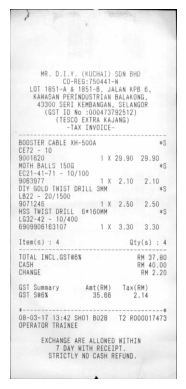

Corresponding OCR output
MR. D.I.¥. (KUCHAT) SDN BHD
CO-REG:750441-W
LOT 1851-A & 1851-B, JALAN KPB 6,
KAWASAN PERINDUSTRIAN BALAKONG,
43300 SERI KEMBANGAN, SELANGOR
(GST ID No :000473792512)
(TESCO EXTRA KAJANG)
-TAX INVOICE-

BOOSTER CABLE XH-500A +*§
CE72 - 10
9001620 1X 29.90 298,90
MOTH BALLS 1506 *§
EC21-41-71 - 10/100
9063977 1X 2,10 2,10
DIY GOLD TWIST DRILL 3MM *§
LB22 - 20/1500
9071246 THX 2,00 2,50
HSS TWIST DRILL 6*160MM *§
LG32-42 - 10/400
6909906163107 1X 3.30 3,30

Item(s) : 4 Qty(s) : 4
TOTAL INCL. GSTe6K RM 37.80
CASH RM 40.00
CHANGE RM 2.20

GST Summary Amt(RM) = Tax(RM)
GST S@6% 35.66 2.14

08-03-17 13:42 SHO1 BO28 12 000017473
OPERATOR TRAINEE

EXCHANGE ARE ALLOWED WITHIN
7 DAY WITH RECEIPT.
STRICTLY NO CASH REFUND.


Image without any preprocessing


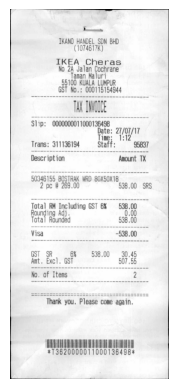

Corresponding OCR output
CE LL eee

bee
TKANO HANDEL. SDN BHD
(1074617K)

IKEA Cheras
No 2A Jalan Cochrane

Taman Maluri
55100 KUALA LUMPUR
GST No.: 000115154944

Slip: 000000001 1000136498
Date: :

Time; 1:1
Trans: 311136194 Staff: 95837

50346155 BOSTRAK WRD 80X50X18
2 pe @ 269.00 538.00 SRS

Total RM Including GST 6% 538.00
Rounding Adj. 0,00

Total Rounded 538.00
Visa -138 .00
SR. «BK ~s538.00 30.45
. Excl, GST 507.55


Image without any preprocessing


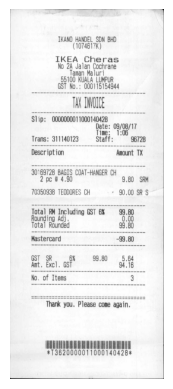

Corresponding OCR output
IKANO HANDEL SDN BHD
(1074617K)

IKEA Cheras
No 2A sig! jenrete

ie n Malur
59100 "KUALA LUMPUR
GST No.; 000115154944

Slip: 0000000011000140428
io fe: O/T

Trans: 311140123 Staff: 96728

Description Amount TX

30169728 BAGIS COAT-HANGER CH
2 pc @ 4,90 9.80 SRM

70350938 TEODORES CH * 90.00 SRS

Total RM Including GST 6% 99.80
Rounding Adj. 0,00

Total Rounded 99.80
Mastercard -99.80

6% 99 .80 5.64
jh ea, GST 94,16
No. of Items 3




In [54]:
# Testing the same for 10 images
for i in range(100, 110):
  temp_image = ds_images['train'][i]
  print('Image without any preprocessing')
  plt.imshow(temp_image['image'])
  plt.axis('off')
  plt.show()
  temp_text = pytesseract.image_to_string(temp_image['image'])
  print('Corresponding OCR output')
  print(temp_text)

In [55]:
def resolution(image):
  width, height = image.size
  print(f'Image resolution: {width}x{height}')

def DPI(image):
  dpi = image.info.get('dpi')
  if dpi:
    print(f'Image DPI: {dpi[0]}x{dpi[1]}')
  else:
    print('Image DPI not found')

In [56]:
# Lets calculate resolution and dpi of few images
for i in range(100, 110):
  temp_image = ds_images['train'][i]['image']
  resolution(temp_image)
  DPI(temp_image)

Image resolution: 888x1615
Image DPI not found
Image resolution: 884x2249
Image DPI not found
Image resolution: 888x1900
Image DPI not found
Image resolution: 936x2915
Image DPI not found
Image resolution: 936x2785
Image DPI not found
Image resolution: 932x1644
Image DPI not found
Image resolution: 936x1681
Image DPI not found
Image resolution: 932x2067
Image DPI not found
Image resolution: 932x2168
Image DPI not found
Image resolution: 932x2246
Image DPI not found


In [57]:
def resolution_flag(image):
  width, height = image.size
  if width < 1000 and height <= 1000:
    return 1


# Lets run a quick loop to identify, images with bad resolution
list_bad_resolution = []
for i in range(778):
  temp_image = ds_images['train'][i]['image']
  if resolution_flag(temp_image) == 1:
    list_bad_resolution.append(ds['train'][i]['file_id'])
    '''
    print('Image with bad resolution')
    print(ds['train'][i]['file_id'])
    print(resolution(temp_image))
    plt.imshow(temp_image)
    plt.axis('off')
    plt.show()
    '''

In [58]:
print(f'Image IDs with bad resolution: {list_bad_resolution}')
print(f'Total number of images with bad resolution: {len(list_bad_resolution)}')

Image IDs with bad resolution: ['X00016469620', 'X00016469622', 'X00016469669', 'X00016469670', 'X00016469671', 'X00016469676', 'X51005230648', 'X51005230657', 'X51005306399', 'X51005453729', 'X51005453802', 'X510056849111', 'X51005684949', 'X51006008197', 'X51006349086', 'X51006441474', 'X51006466060', 'X51006466062', 'X51006466070', 'X51006466778', 'X51006502529', 'X51006555072', 'X51006557209', 'X51006647933', 'X51007419197', 'X51009453729']
Total number of images with bad resolution: 26


In [59]:
# The number of images with bad resolution is really less, hence resolution improvement in the preprocessing is not an issue

# Let us run a quick evaluation metric tes

In [60]:
# The results of the OCR aren't great without any preprocessing
# We will design a preprocessing pipeline now

from typing import Any

In [61]:
def image_to_cv2(image_value: Any) -> np.ndarray:
    if isinstance(image_value, np.ndarray):
        image = image_value
    elif hasattr(image_value, 'convert'):
        image = np.array(image_value.convert('RGB'))
    else:
        image = cv2.imread(str(image_value))

    if image is None:
        raise ValueError('Could not read image')
    if image.ndim == 2:
        return image
    return cv2.cvtColor(image, cv2.COLOR_RGB2BGR)


def deskew(image: np.ndarray) -> np.ndarray:
    gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    coords = np.column_stack(np.where(gray < 250))
    if len(coords) < 20:
        return image
    angle = cv2.minAreaRect(coords)[-1]
    angle = -(90 + angle) if angle < -45 else -angle
    if abs(angle) < 0.2:
        return image
    h, w = gray.shape[:2]
    matrix = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REPLICATE)


def preprocess_image(image: np.ndarray, mode: str = 'adaptive') -> np.ndarray:
    gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    if mode == 'none':
        return image
    if mode == 'basic':
        return gray
    if mode == 'adaptive':
        return cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 31, 11
        )
    if mode == 'morph':
        kernel = np.ones((2, 2), np.uint8)
        return cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)
    if mode == 'deskew':
        return deskew(gray)
    raise ValueError(f'Unknown preprocessing mode: {mode}')

# This function helps in upscaling of images with both higher and lower dimensions
"""
    NOTE : The resize_for_ocr function here is not quiet useful for the INVOICE dataset here, as every image is already within the standard range.
"""
def resize_for_ocr(gray: np.ndarray, min_height: int = 64, max_height: int = 4000) -> np.ndarray:
    height, width = gray.shape[:2]
    if height <= 0 or width <= 0:
        raise ValueError("Image has invalid dimensions.")

    if height < min_height:
        scale = min_height / height
    elif height > max_height:
        scale = max_height / height
    else:
        return gray

    new_width = max(1, round(width * scale))
    new_height = max(1, round(height * scale))

    interpolation = (
        cv2.INTER_CUBIC if scale > 1
        else cv2.INTER_AREA
    )

    return cv2.resize(gray, (new_width, new_height), interpolation=interpolation)

In [62]:
# CONTROL THE METRICS IN PREPROSESSING AND TESSERACT

TESSERACT_LANG = 'eng'
TESSERACT_PSM = 6
TESSERACT_OEM = 3
TESSERACT_EXTRA_CONFIG = ''
PREPROCESS_MODE = 'adaptive'
MAX_SAMPLES = None  # Set to a small number such as 25 for a smoke test.


def run_tesseract(image: np.ndarray, lang: str = TESSERACT_LANG,
                  psm: int = TESSERACT_PSM, oem: int = TESSERACT_OEM,
                  extra_config: str = TESSERACT_EXTRA_CONFIG) -> str:
    config = f'--oem {oem} --psm {psm} {extra_config}'.strip()
    return pytesseract.image_to_string(image, lang=lang, config=config).strip()


def normalize_spaces(value: Any) -> str:
    return re.sub(r'\s+', ' ', str(value or '')).strip()


def extract_invoice_fields(ocr_text: str) -> dict[str, str]:
    lines = [normalize_spaces(line) for line in ocr_text.splitlines()]
    lines = [line for line in lines if line]
    text = ' '.join(lines)

    date_match = re.search(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', text)
    total_match = re.search(
        r'(?i)\b(?:total|amount due|grand total)\s*[:=-]?\s*'
        r'[^0-9]*([0-9][0-9,]*\.?[0-9]{0,2})', text
    )
    address_match = re.search(
        r'(?i)\b(address)\s*[:=-]?\s*(.*?)(?=\b(?:date|total)\b|$)',
        text
    )

    return {
        'company': lines[0] if lines else '',
        'date': date_match.group(0) if date_match else '',
        'address': normalize_spaces(address_match.group(2)) if address_match else '',
        'total': total_match.group(1) if total_match else '',
    }

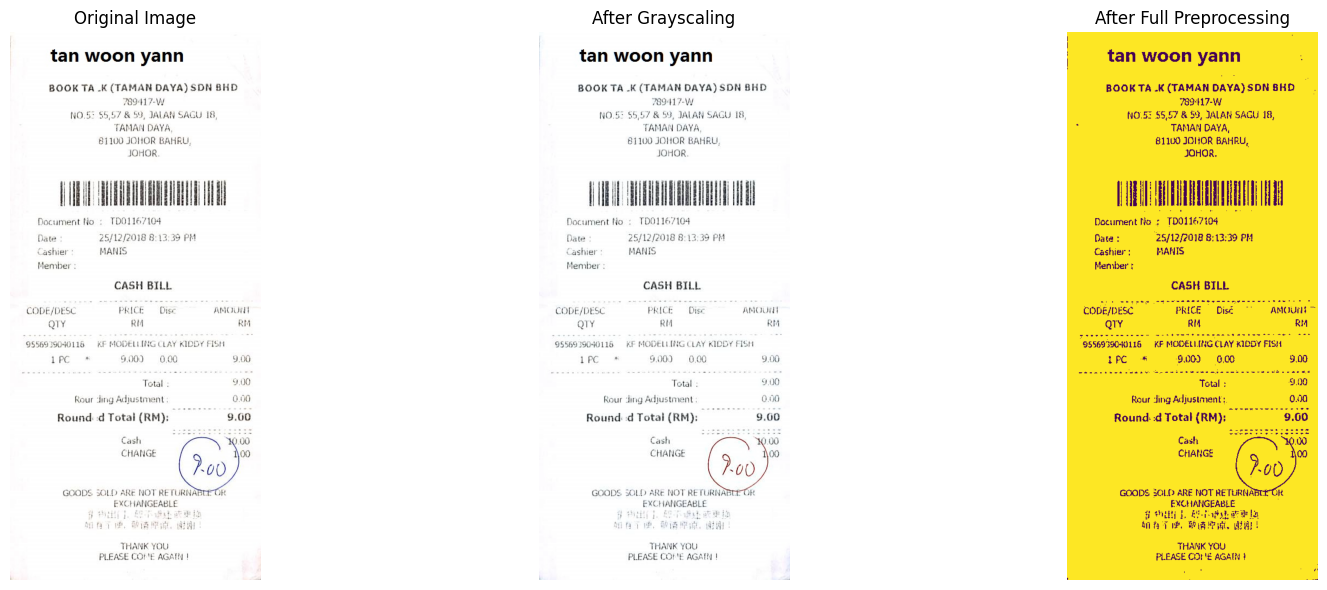

######################################################################################################################################################


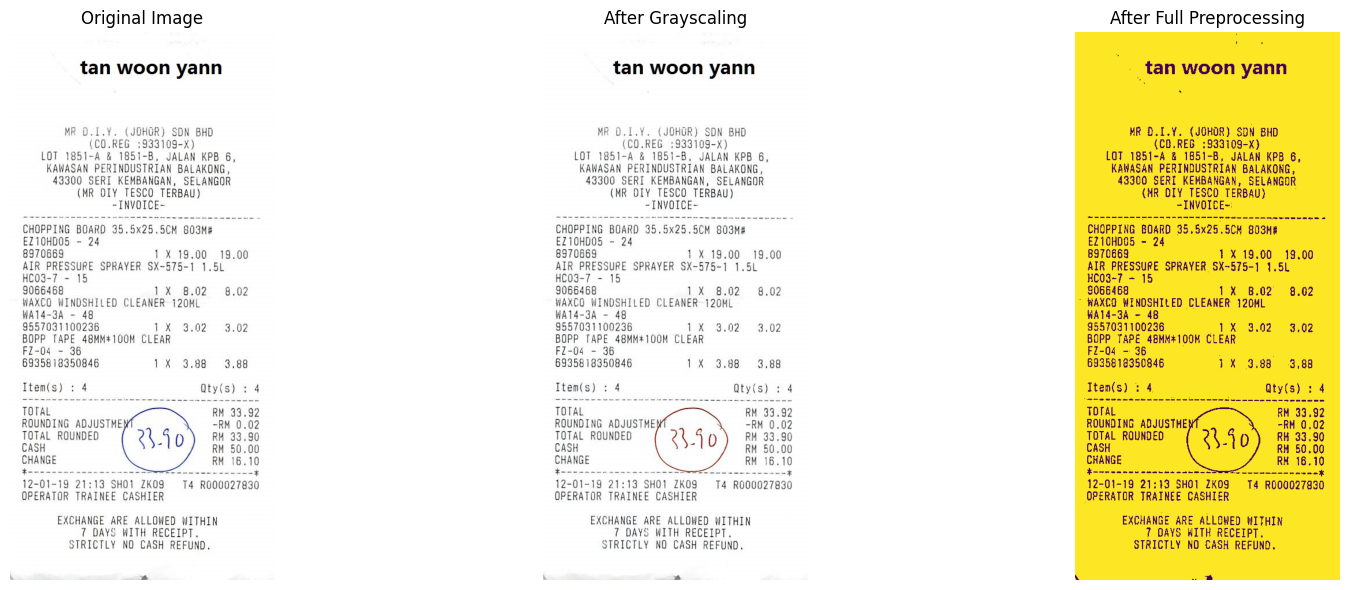

######################################################################################################################################################


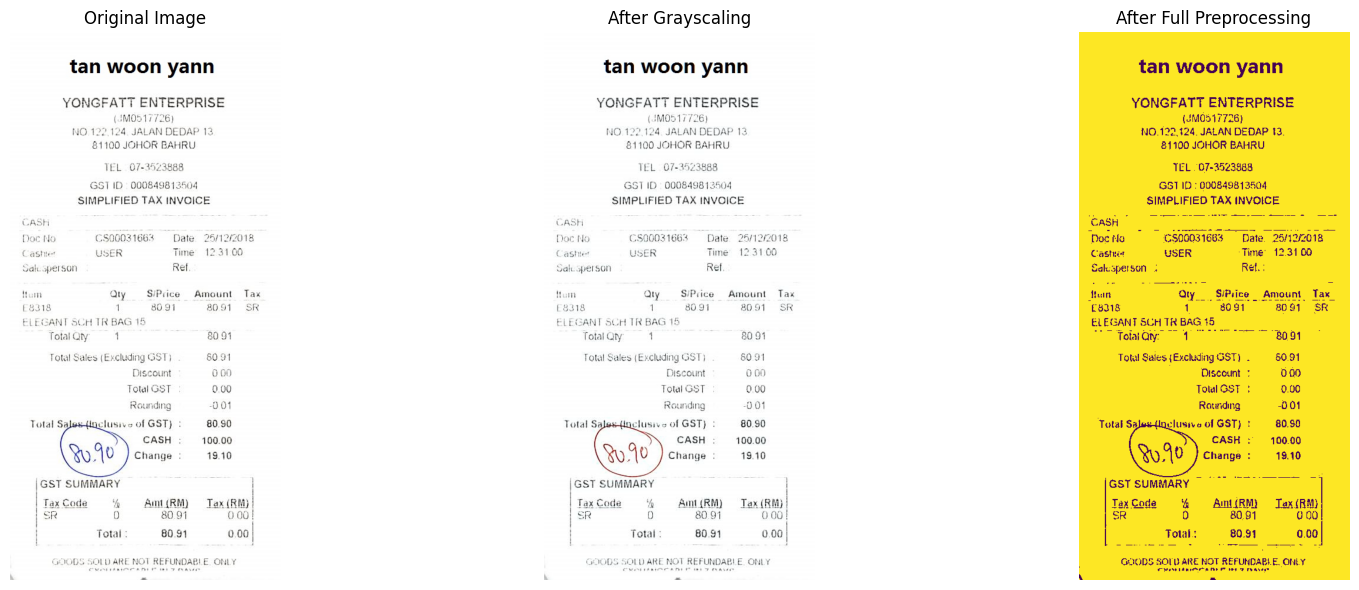

######################################################################################################################################################


In [63]:
# To fix this error, install the opencv-python library.
!pip install opencv-python

import cv2

def run_tesseract(image: np.ndarray, lang: str = 'eng', psm: int = 3, oem: int = 3, extra_config: str = '') -> str:
    config = f'--oem {oem} --psm {psm}'
    if extra_config:
        config = f'{config} {extra_config}'
    return pytesseract.image_to_string(image, lang=lang, config=config).strip()


for i in range(3):
  sample = ds_images["train"]['image'][i]
  sample_1 = image_to_cv2(sample)
  sample_2 = resize_for_ocr(sample_1)
  sample_3 = deskew(sample_2)
  sample_data = ds['train']
  image_bgr = image_to_cv2(sample)
  processed = preprocess_image(image_bgr, mode=PREPROCESS_MODE)

  fig, axes = plt.subplots(1, 3, figsize=(18, 6))

  # Original image
  axes[0].imshow(sample)
  axes[0].set_title("Original Image")
  axes[0].axis("off")

  # Grayscale image
  axes[1].imshow(image_bgr)
  axes[1].set_title("After Grayscaling")
  axes[1].axis("off")

  # Fully processed image
  axes[2].imshow(processed)
  axes[2].set_title("After Full Preprocessing")
  axes[2].axis("off")

  plt.tight_layout()
  plt.show()
  print(150*'#')
  '''
  prediction = run_tesseract(processed, TESSERACT_LANG, TESSERACT_PSM, TESSERACT_OEM, TESSERACT_EXTRA_CONFIG)
  print('Reference:', sample_data['entities'][i])
  print('Prediction:', prediction)
  print('Normalized CER:', cer(normalize_text(sample_data['entities'][i]), normalize_text(prediction)))
  print('Normalized WER:', wer(normalize_text(sample_data['entities'][i]), normalize_text(prediction)))
  '''

In [64]:
def normalize_text(value: Any) -> str:
    text = unicodedata.normalize('NFKC', str(value or '')).casefold()
    return re.sub(r'\s+', ' ', text).strip()


def edit_distance(a: str, b: str) -> int:
    previous = list(range(len(b) + 1))
    for i, char_a in enumerate(a, 1):
        current = [i]
        for j, char_b in enumerate(b, 1):
            current.append(min(current[-1] + 1, previous[j] + 1,
                               previous[j - 1] + (char_a != char_b)))
        previous = current
    return previous[-1]


def calculate_cer(reference: str, prediction: str) -> float:
    return edit_distance(reference, prediction) / max(len(reference), 1)


def calculate_wer(reference: str, prediction: str) -> float:
    reference_words, prediction_words = reference.split(), prediction.split()
    return edit_distance(reference_words, prediction_words) / max(len(reference_words), 1)

In [65]:
FIELDS = ('company', 'date', 'address', 'total')


import re
import unicodedata
from typing import Any


# Modified
def normalize_field(value: Any, field: str) -> str:
    if value is None:
        return ""

    value = unicodedata.normalize(
        "NFKC",
        str(value)
    ).casefold()

    # Normalize line breaks and whitespace
    value = value.replace("\n", " ")
    value = re.sub(r"\s+", " ", value).strip()

    if field == "total":
        # Remove currency symbols, commas, and spaces
        value = re.sub(r"[^0-9.\-]", "", value)

        if value:
            try:
                value = f"{float(value):.2f}"
            except ValueError:
                value = ""

    elif field == "date":
        # Treat common date separators consistently
        value = re.sub(r"[./]", "-", value)
        value = re.sub(r"\s*-\s*", "-", value)

    elif field in {"company", "address"}:
        # Ignore punctuation differences for text comparison
        value = re.sub(r"[^\w\s]", "", value)
        value = re.sub(r"\s+", " ", value).strip()

    return value

def field_is_correct(reference: Any, prediction: Any, field: str) -> bool:
    return normalize_field(reference, field) == normalize_field(prediction, field)


#=======================================================================================================#
#===============================CONTROL THE NUMBER OF SAMPLES CONSIDERED================================#
MAX_SAMPLES = 100
#=======================================================================================================#
n_samples = len(ds_images['train']) if MAX_SAMPLES is None else min(MAX_SAMPLES, len(ds_images['train']))
results = []

for i in tqdm(range(n_samples), desc='Evaluating invoices'):
    image = image_to_cv2(ds_images['train']['image'][i])
    ground_truth = ds['train']['entities'][i]

    original_text = run_tesseract(image)
    processed_image = preprocess_image(image, PREPROCESS_MODE)
    processed_text = run_tesseract(processed_image)

    original_fields = extract_invoice_fields(original_text)
    processed_fields = extract_invoice_fields(processed_text)
    reference_text = normalize_text(' '.join(str(ground_truth.get(f, '')) for f in FIELDS))

    row = {'index': i}
    for prefix, fields, text in (
        ('original', original_fields, original_text),
        ('processed', processed_fields, processed_text),
    ):
        row[f'{prefix}_field_accuracy'] = np.mean([
            field_is_correct(ground_truth.get(f, ''), fields.get(f, ''), f)
            for f in FIELDS
        ])
        row[f'{prefix}_cer'] = calculate_cer(reference_text, normalize_text(text))
        row[f'{prefix}_wer'] = calculate_wer(reference_text, normalize_text(text))
        for field in FIELDS:
            row[f'{prefix}_{field}'] = field_is_correct(
                ground_truth.get(field, ''), fields.get(field, ''), field
            )
    results.append(row)

results_df = pd.DataFrame(results)
summary = {
    'samples': len(results_df),
    'original': {
        'field_accuracy': results_df['original_field_accuracy'].mean(),
        'CER': results_df['original_cer'].mean(),
        'WER': results_df['original_wer'].mean(),
    },
    'processed': {
        'field_accuracy': results_df['processed_field_accuracy'].mean(),
        'CER': results_df['processed_cer'].mean(),
        'WER': results_df['processed_wer'].mean(),
    },
}
summary['improvement'] = {
    'field_accuracy': summary['processed']['field_accuracy'] - summary['original']['field_accuracy'],
    'CER': summary['original']['CER'] - summary['processed']['CER'],
    'WER': summary['original']['WER'] - summary['processed']['WER'],
}
print(summary)

print('\nPer-field processed accuracy:')
for field in FIELDS:
    print(f'{field}: {results_df[f"processed_{field}"].mean():.3f}')

Evaluating invoices:   0%|          | 0/100 [00:00<?, ?it/s]

{'samples': 100, 'original': {'field_accuracy': np.float64(0.23), 'CER': np.float64(4.57725365808799), 'WER': np.float64(5.547581251875807)}, 'processed': {'field_accuracy': np.float64(0.21), 'CER': np.float64(4.765094583401795), 'WER': np.float64(5.940227093657976)}, 'improvement': {'field_accuracy': np.float64(-0.020000000000000018), 'CER': np.float64(-0.1878409253138047), 'WER': np.float64(-0.3926458417821683)}}

Per-field processed accuracy:
company: 0.190
date: 0.540
address: 0.000
total: 0.110
